# Müllklassifikation – Gesamtnotebook

Dieses Notebook vereint die komplette Pipeline des Projekts in **einer Datei**:

1. **Datenaufbereitung**
2. **Training**
3. **Vorhersage (Predictor)**

Dabei wurden die Inhalte der bisherigen Einzeldateien zusammengeführt, aber **nicht kaputt vereinfacht**.  
Wichtige Beschreibungen in Markdown bleiben erhalten oder wurden nur sprachlich gestrafft.


## Einleitung

Im Rahmen des Data-Lab-Kurses wurde ein Machine-Learning-Projekt entwickelt, das den praktischen Nutzen von Bildklassifikation im Kontext der Mülltrennung untersucht. Ziel des Projekts ist es, anhand von Bilddaten automatisiert zu erkennen, zu welcher Abfallkategorie ein Objekt gehört.

Damit adressiert das Projekt ein reales Problem: Fehlwürfe im Abfall führen zu hohen Sortierkosten, mindern die Recyclingqualität und erschweren ressourceneffizientes Handeln. Ein KI-gestütztes System könnte hier einen Beitrag leisten, indem es Nutzerinnen und Nutzer im Alltag unterstützt oder Sortierprozesse teilautomatisiert.

Ein zentraler Bestandteil des Projekts ist eine saubere und reproduzierbare Datenvorbereitung, die die Grundlage für jedes verlässliche Klassifikationsmodell bildet. Dieser Prozess umfasst die Sichtung, Analyse und Strukturierung des Datensatzes, das Vereinheitlichen der Bildgrößen, das Erstellen eines Train-Validation-Test-Splits sowie das Generieren künstlich erweiterter Trainingsdaten durch Datenaugmentation.


## Anleitung

1. **Run all**
2. Bei der Reset-Abfrage optional **`j`** eingeben, wenn `dataset-224`, `dataset-split` und `dataset-augmented` neu erzeugt werden sollen
3. Warten, bis das Notebook vollständig durchgelaufen ist
4. Danach kann unten im Predictor ein Bildpfad getestet werden


## 1. Setup & Bibliotheken

In [3]:
import os
import stat
import shutil
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image, ImageEnhance
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


## 2. Projektpfad setzen und Datensatz prüfen

Wir setzen das Arbeitsverzeichnis auf unseren Projektordner und prüfen, ob die nötigen Ordner gefunden werden.


In [ ]:
DATASET_ORIGINAL_DIR = "dataset-original"

def find_project_root(start_path, required_names=None):
    if required_names is None:
        required_names = [DATASET_ORIGINAL_DIR]

    current = start_path
    while True:
        entries = set(os.listdir(current))
        if all(name in entries for name in required_names):
            return current

        parent = os.path.dirname(current)
        if parent == current:
            return None
        current = parent

print("Aktueller Arbeitsordner:", os.getcwd())

project_root = find_project_root(os.getcwd(), required_names=[DATASET_ORIGINAL_DIR])

if project_root is None:
    raise FileNotFoundError(
        f"'{DATASET_ORIGINAL_DIR}' konnte nicht gefunden werden. "
        "Starte das Notebook im Projektordner oder in einem Unterordner davon."
    )

if os.getcwd() != project_root:
    os.chdir(project_root)
    print("Arbeitsverzeichnis automatisch gesetzt auf:", project_root)
else:
    print("Arbeitsverzeichnis war schon korrekt gesetzt.")

print("dataset-original gefunden:", os.path.isdir(DATASET_ORIGINAL_DIR))
print("Inhalt des Projektordners:", os.listdir())


Aktueller Arbeitsordner: e:\Studium\5.Semester\Data Lab\DataLabTrash
Arbeitsverzeichnis war schon korrekt gesetzt.
dataset-original gefunden: True
Inhalt des Projektordners: ['.git', 'dataset-224', 'dataset-augmented', 'dataset-original', 'dataset-split', 'README.md', 'requirements.txt', 'src']


## 3. Alte generierte Ordner optional löschen

Diese Zelle löscht bei Bedarf alte generierte Ordner, damit Resize, Split und Augmentation sauber neu erzeugt werden können.

**Wichtig:** Erst den Projektpfad korrekt setzen, dann löschen.


In [ ]:
def handle_remove_readonly(func, path, exc):
    os.chmod(path, stat.S_IWRITE)
    func(path)

folders_to_reset = ["dataset-224", "dataset-split", "dataset-augmented"]

user_input = input("Ordner neu erzeugen? (j/n): ")

if user_input.lower() == "j":
    for folder in folders_to_reset:
        if os.path.exists(folder):
            shutil.rmtree(folder, onerror=handle_remove_readonly)
            print(f"Gelöscht: {folder}")
        else:
            print(f"Nicht vorhanden (ok): {folder}")
else:
    print("Reset übersprungen.")


Gelöscht: dataset-224
Gelöscht: dataset-split
Gelöscht: dataset-augmented


## 4. Klassen automatisch einlesen

Wir lesen die vorhandenen Klassen automatisch aus `dataset-original` ein.  
Dadurch bleibt der Workflow flexibel, falls neue Kategorien hinzukommen.


In [ ]:
classes = sorted([
    d for d in os.listdir(DATASET_ORIGINAL_DIR)
    if os.path.isdir(os.path.join(DATASET_ORIGINAL_DIR, d))
])

print("Gefundene Klassen in dataset-original:", classes)


Gefundene Klassen in dataset-original: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


## 5. Beispielbilder anzeigen

Wir zeigen je Klasse einige Beispielbilder, um die Datenqualität zu prüfen.


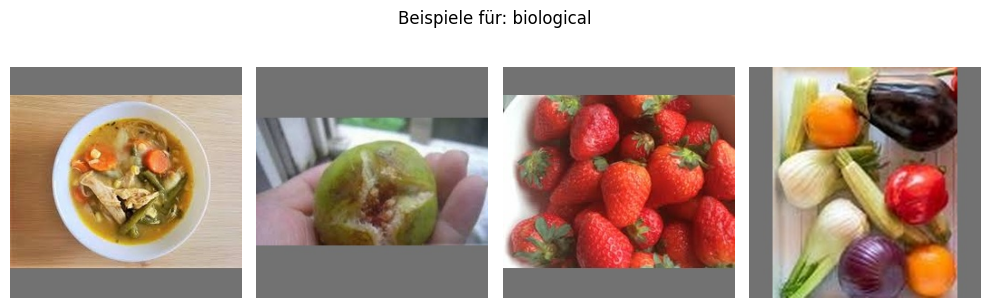

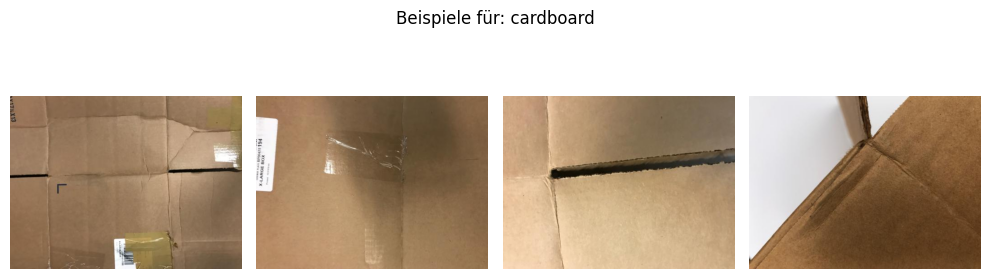

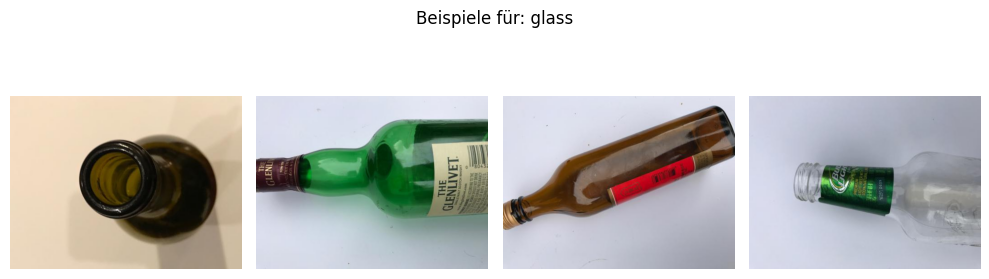

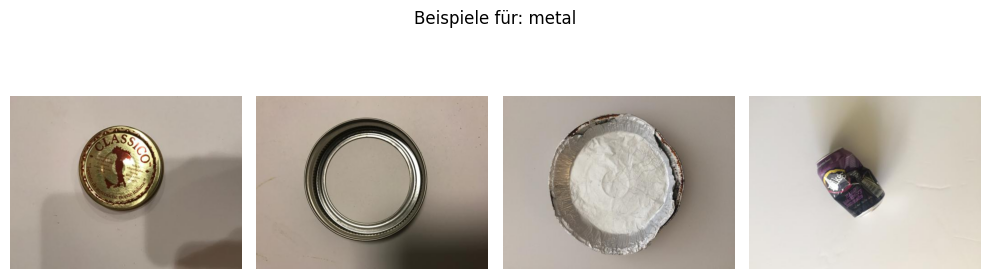

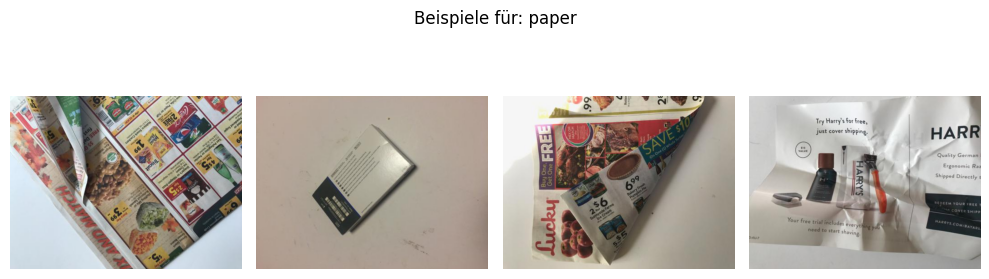

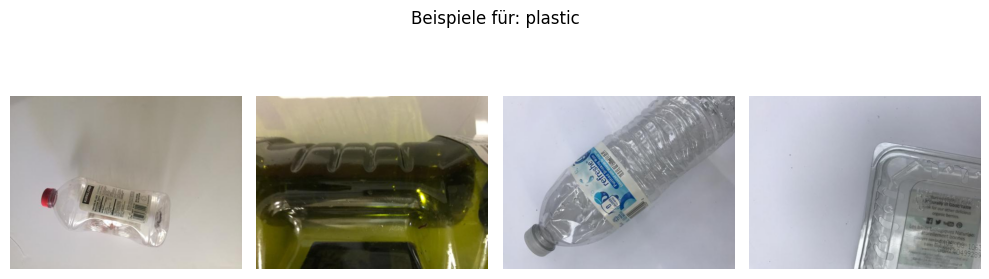

In [ ]:
def show_examples(cls, n=4):
    folder = os.path.join(DATASET_ORIGINAL_DIR, cls)
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    n = min(n, len(files))

    if n == 0:
        print(f"Keine Bilder in Klasse: {cls}")
        return

    sample_files = random.sample(files, n)

    plt.figure(figsize=(10, 3))
    for i, file in enumerate(sample_files):
        img_path = os.path.join(folder, file)
        with Image.open(img_path) as img:
            img = img.copy()

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(f"Beispiele für: {cls}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

for cls in classes:
    show_examples(cls, n=4)


## 6. Bildgrößen analysieren

Wir analysieren die Bildgrößen und die Häufigkeit der Bildgrößen. Das ist wichtig, bevor wir sie auf eine einheitliche Zielgröße von **224×224** skalieren.


In [ ]:
sizes = []

for cls in classes:
    folder = os.path.join(DATASET_ORIGINAL_DIR, cls)
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        if os.path.isfile(path):
            with Image.open(path) as img:
                sizes.append(img.size)

print("Häufigste Bildgrößen:", Counter(sizes).most_common(10))


Häufigste Bildgrößen: [((512, 384), 2390), ((256, 256), 699)]


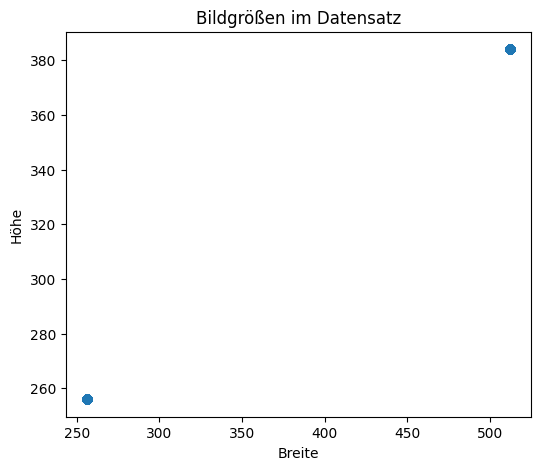

In [ ]:
widths = [w for (w, h) in sizes]
heights = [h for (w, h) in sizes]

plt.figure(figsize=(6, 5))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Breite")
plt.ylabel("Höhe")
plt.title("Bildgrößen im Datensatz")
plt.show()


## 7. Resizing auf 224×224

Wir skalieren alle Bilder auf eine einheitliche Größe von **224×224 Pixeln** und speichern sie im Ordner `dataset-224`.


In [ ]:
INPUT_DIR = "dataset-original"
OUTPUT_DIR = "dataset-224"
TARGET_SIZE = (224, 224)

os.makedirs(OUTPUT_DIR, exist_ok=True)

for cls in classes:
    input_class = os.path.join(INPUT_DIR, cls)
    output_class = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class, exist_ok=True)

    for file in os.listdir(input_class):
        input_path = os.path.join(input_class, file)
        output_path = os.path.join(output_class, file)

        if not os.path.isfile(input_path):
            continue

        with Image.open(input_path) as img:
            img = img.convert("RGB")
            img = img.resize(TARGET_SIZE)
            img.save(output_path)

print("Resize abgeschlossen. Alle Bilder wurden nach dataset-224 resized.")


Resize abgeschlossen. Alle Bilder wurden nach dataset-224 resized.


## 8. Train/Validation/Test Split

Wir splitten den Datensatz in **70% Training**, **15% Validation** und **15% Test**.


In [ ]:
INPUT_DIR = "dataset-224"
OUTPUT_BASE = "dataset-split"

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_BASE, split, cls), exist_ok=True)

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    files = [
        f for f in os.listdir(os.path.join(INPUT_DIR, cls))
        if os.path.isfile(os.path.join(INPUT_DIR, cls, f))
    ]

    train_files, temp_files = train_test_split(
        files,
        test_size=(1 - train_ratio),
        random_state=42
    )
    val_files, test_files = train_test_split(
        temp_files,
        test_size=(test_ratio / (test_ratio + val_ratio)),
        random_state=42
    )

    for f in train_files:
        shutil.copy(
            os.path.join(INPUT_DIR, cls, f),
            os.path.join(OUTPUT_BASE, "train", cls, f)
        )
    for f in val_files:
        shutil.copy(
            os.path.join(INPUT_DIR, cls, f),
            os.path.join(OUTPUT_BASE, "val", cls, f)
        )
    for f in test_files:
        shutil.copy(
            os.path.join(INPUT_DIR, cls, f),
            os.path.join(OUTPUT_BASE, "test", cls, f)
        )

print("Split abgeschlossen!")


Split abgeschlossen!


In [ ]:
for split in ["train", "val", "test"]:
    print(split)
    for cls in classes:
        count = len(os.listdir(os.path.join("dataset-split", split, cls)))
        print(f"  {cls}: {count} Bilder")


train
  biological: 489 Bilder
  cardboard: 282 Bilder
  glass: 350 Bilder
  metal: 286 Bilder
  paper: 415 Bilder
  plastic: 337 Bilder
val
  biological: 105 Bilder
  cardboard: 60 Bilder
  glass: 75 Bilder
  metal: 62 Bilder
  paper: 89 Bilder
  plastic: 72 Bilder
test
  biological: 105 Bilder
  cardboard: 61 Bilder
  glass: 76 Bilder
  metal: 62 Bilder
  paper: 90 Bilder
  plastic: 73 Bilder


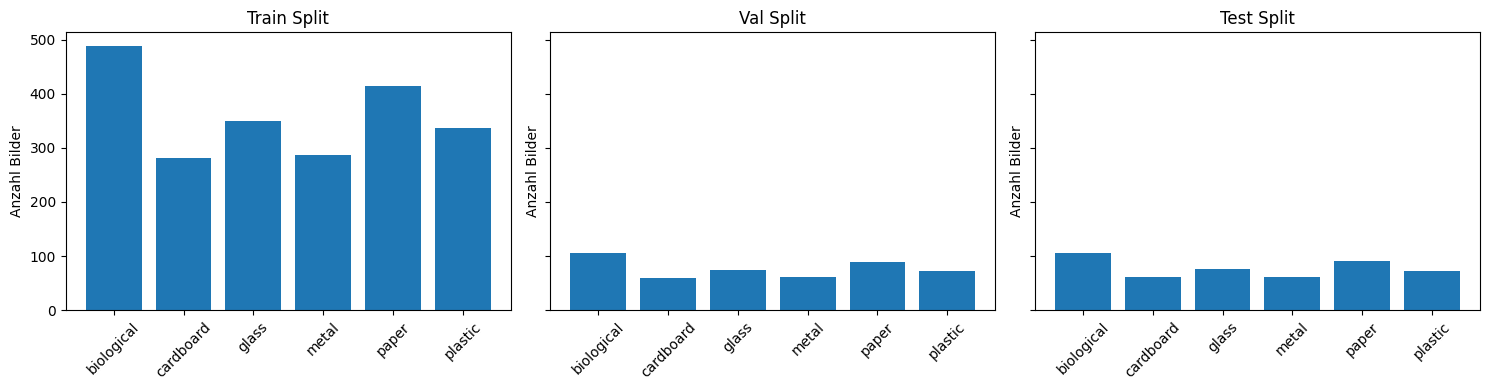

In [ ]:
splits = ["train", "val", "test"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

x = np.arange(len(classes))

for i, split in enumerate(splits):
    counts = [len(os.listdir(os.path.join("dataset-split", split, cls))) for cls in classes]
    axes[i].bar(x, counts)
    axes[i].set_title(f"{split.capitalize()} Split")
    axes[i].set_ylabel("Anzahl Bilder")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(classes, rotation=45)

plt.tight_layout()
plt.show()


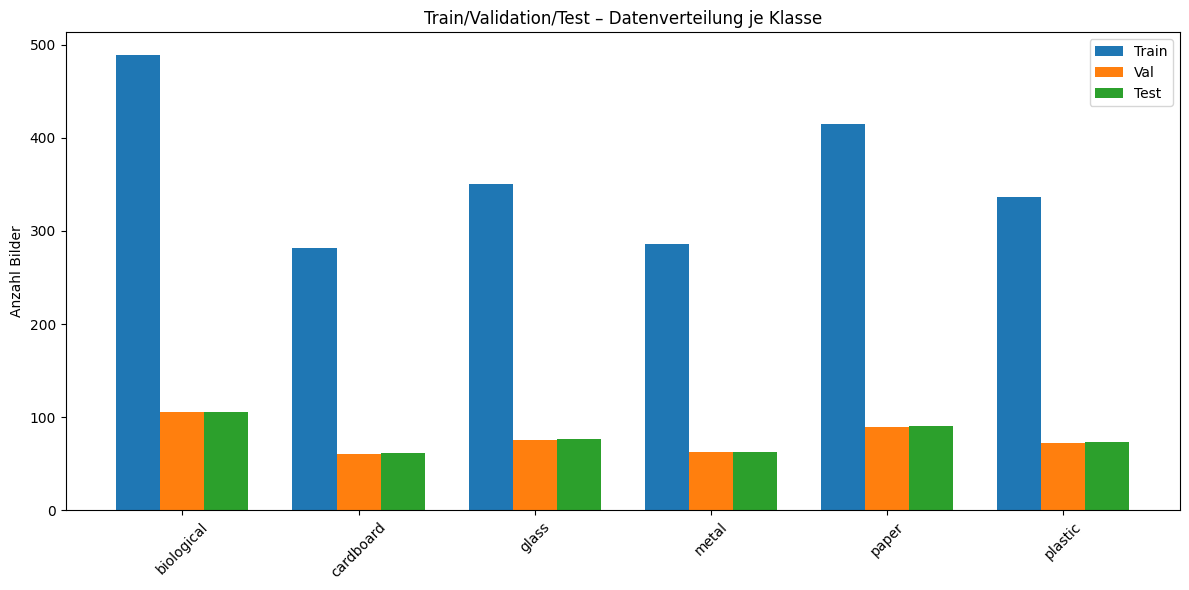

In [ ]:
split_counts = {
    split: [len(os.listdir(os.path.join("dataset-split", split, cls))) for cls in classes]
    for split in splits
}

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12, 6))
for i, split in enumerate(splits):
    plt.bar(x + i * width, split_counts[split], width=width, label=split.capitalize())

plt.xticks(x + width, classes, rotation=45)
plt.ylabel("Anzahl Bilder")
plt.title("Train/Validation/Test – Datenverteilung je Klasse")
plt.legend()
plt.tight_layout()
plt.show()


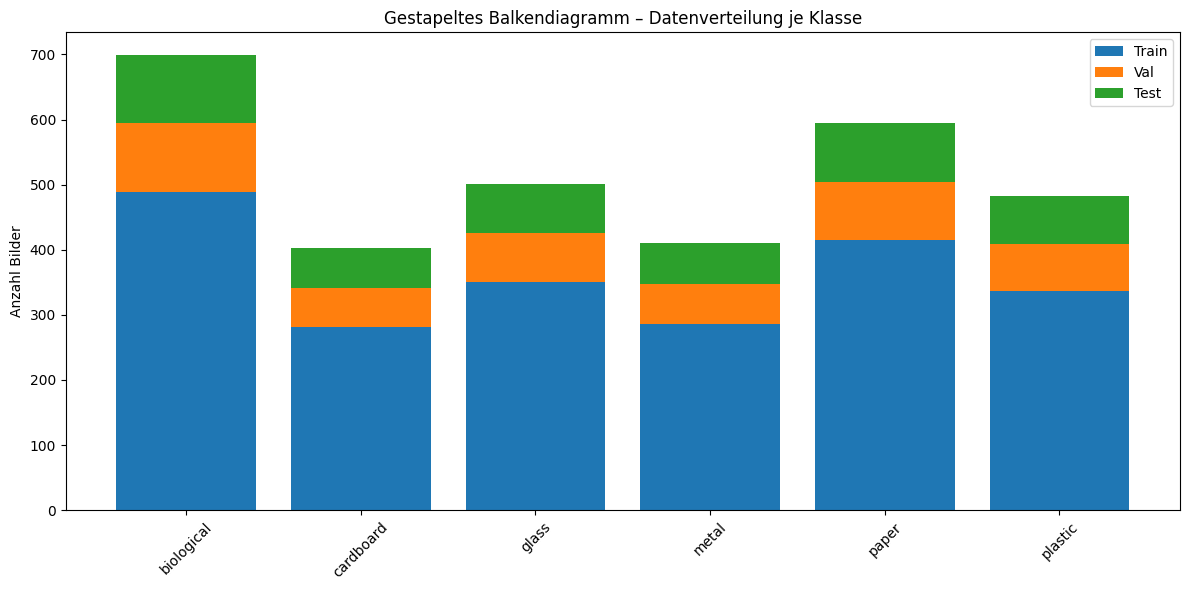

In [ ]:
train_counts = [len(os.listdir(os.path.join("dataset-split/train", cls))) for cls in classes]
val_counts = [len(os.listdir(os.path.join("dataset-split/val", cls))) for cls in classes]
test_counts = [len(os.listdir(os.path.join("dataset-split/test", cls))) for cls in classes]

x = np.arange(len(classes))

plt.figure(figsize=(12, 6))
plt.bar(x, train_counts, label="Train")
plt.bar(x, val_counts, bottom=train_counts, label="Val")
plt.bar(x, test_counts, bottom=np.array(train_counts) + np.array(val_counts), label="Test")

plt.xticks(x, classes, rotation=45)
plt.ylabel("Anzahl Bilder")
plt.title("Gestapeltes Balkendiagramm – Datenverteilung je Klasse")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Datenaugmentation

Wir erweitern die Trainingsdaten um Rotation, Spiegelung sowie Helligkeits- und Kontrastvariationen.


In [ ]:
INPUT_DIR = "dataset-split/train"
OUTPUT_DIR = "dataset-augmented/train"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def augment_image(img):
    if random.random() < 0.5:
        img = img.rotate(random.randint(-15, 15))
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() < 0.4:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))
    if random.random() < 0.4:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.3))
    return img

for cls in classes:
    input_class = os.path.join(INPUT_DIR, cls)
    output_class = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class, exist_ok=True)

    files = [f for f in os.listdir(input_class) if os.path.isfile(os.path.join(input_class, f))]
    print(f"{cls}: {len(files)} Trainingsbilder gefunden")

    for file in files:
        img_path = os.path.join(input_class, file)

        with Image.open(img_path) as img:
            img = img.convert("RGB")
            base_img = img.copy()

        base_img.save(os.path.join(output_class, file))

        for i in range(2):
            aug = augment_image(base_img.copy())
            base, ext = os.path.splitext(file)
            aug.save(os.path.join(output_class, f"{base}_aug{i}{ext}"))

print("Augmentation fertig!")


biological: 489 Trainingsbilder gefunden
cardboard: 282 Trainingsbilder gefunden
glass: 350 Trainingsbilder gefunden
metal: 286 Trainingsbilder gefunden
paper: 415 Trainingsbilder gefunden
plastic: 337 Trainingsbilder gefunden
Augmentation fertig!


In [ ]:
for cls in classes:
    count = len(os.listdir(os.path.join("dataset-augmented/train", cls)))
    print(cls, ":", count)


biological : 1467
cardboard : 846
glass : 1050
metal : 858
paper : 1245
plastic : 1011


## 10. Training – 6 Klassen mit vorhandenen Daten

Dieses Kapitel trainiert ein CNN direkt auf den bereits vorhandenen Datenordnern und erzeugt **keine neuen Datensatzordner**.

### Verwendete Klassen
- `biological`
- `cardboard`
- `glass`
- `metal`
- `paper`
- `plastic`

### Wichtig
- `trash` wird nicht mehr verwendet
- Es werden nur die gewünschten Klassen geladen
- Für das Training kann optional der augmentierte Trainingsordner genutzt werden


In [ ]:
TARGET_CLASSES = ["biological", "cardboard", "glass", "metal", "paper", "plastic"]
USE_AUGMENTED_TRAIN = True

if USE_AUGMENTED_TRAIN:
    train_dir = os.path.join("dataset-augmented", "train")
else:
    train_dir = os.path.join("dataset-split", "train")

val_dir = os.path.join("dataset-split", "val")
test_dir = os.path.join("dataset-split", "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20

print("Train-Verzeichnis:", train_dir)
print("Validation-Verzeichnis:", val_dir)
print("Test-Verzeichnis:", test_dir)
print("Zielklassen:", TARGET_CLASSES)


Train-Verzeichnis: dataset-augmented\train
Validation-Verzeichnis: dataset-split\val
Test-Verzeichnis: dataset-split\test
Zielklassen: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


## 11. Vorhandene Ordner prüfen

Hier wird geprüft, ob die Verzeichnisse existieren und welche Klassenordner darin liegen.


In [ ]:
print("train_dir existiert:", os.path.isdir(train_dir))
print("val_dir existiert:", os.path.isdir(val_dir))
print("test_dir existiert:", os.path.isdir(test_dir))

print("\nKlassen in train_dir:", os.listdir(train_dir) if os.path.isdir(train_dir) else "fehlt")
print("Klassen in val_dir:", os.listdir(val_dir) if os.path.isdir(val_dir) else "fehlt")
print("Klassen in test_dir:", os.listdir(test_dir) if os.path.isdir(test_dir) else "fehlt")

missing_train = [cls for cls in TARGET_CLASSES if not os.path.isdir(os.path.join(train_dir, cls))]
missing_val = [cls for cls in TARGET_CLASSES if not os.path.isdir(os.path.join(val_dir, cls))]
missing_test = [cls for cls in TARGET_CLASSES if not os.path.isdir(os.path.join(test_dir, cls))]

if missing_train or missing_val or missing_test:
    raise FileNotFoundError(
        "Es fehlen Klassenordner.\n"
        f"Fehlend in train: {missing_train}\n"
        f"Fehlend in val: {missing_val}\n"
        f"Fehlend in test: {missing_test}\n"
        "Prüfe, ob die Datenaufbereitung vorher vollständig gelaufen ist."
    )


train_dir existiert: True
val_dir existiert: True
test_dir existiert: True

Klassen in train_dir: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']
Klassen in val_dir: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']
Klassen in test_dir: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


## 12. Dateipfade nur für die gewünschten Klassen sammeln

Da in den Ordnern andere Klassen liegen können, sammeln wir gezielt nur die Klassen aus `TARGET_CLASSES`.


In [ ]:
label_to_index = {label: idx for idx, label in enumerate(TARGET_CLASSES)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

def collect_filepaths(base_dir, class_names):
    filepaths = []
    labels = []

    for cls in class_names:
        cls_dir = os.path.join(base_dir, cls)

        if not os.path.isdir(cls_dir):
            raise FileNotFoundError(f"Klassenordner nicht gefunden: {cls_dir}")

        for file in os.listdir(cls_dir):
            path = os.path.join(cls_dir, file)
            if os.path.isfile(path):
                filepaths.append(path)
                labels.append(label_to_index[cls])

    return pd.DataFrame({
        "filepath": filepaths,
        "label": labels
    })

train_df = collect_filepaths(train_dir, TARGET_CLASSES)
val_df = collect_filepaths(val_dir, TARGET_CLASSES)
test_df = collect_filepaths(test_dir, TARGET_CLASSES)

print("Train:", len(train_df), "Bilder")
print("Val:", len(val_df), "Bilder")
print("Test:", len(test_df), "Bilder")

train_df.head()


Train: 6477 Bilder
Val: 463 Bilder
Test: 467 Bilder


,filepath,label
0,dataset-augmented\train\biological\biological_...,0
1,dataset-augmented\train\biological\biological_...,0
2,dataset-augmented\train\biological\biological_...,0
3,dataset-augmented\train\biological\biological_...,0
4,dataset-augmented\train\biological\biological_...,0


## 13. Klassenverteilung prüfen

Diese Zelle zeigt, wie viele Bilder pro Klasse in Train, Validation und Test vorhanden sind.


In [ ]:
def class_counts(df, name):
    counts = df["label"].map(index_to_label).value_counts().sort_index()
    print(f"\n{name}")
    print(counts)

class_counts(train_df, "Train")
class_counts(val_df, "Validation")
class_counts(test_df, "Test")



Train
label
biological    1467
cardboard      846
glass         1050
metal          858
paper         1245
plastic       1011
Name: count, dtype: int64

Validation
label
biological    105
cardboard      60
glass          75
metal          62
paper          89
plastic        72
Name: count, dtype: int64

Test
label
biological    105
cardboard      61
glass          76
metal          62
paper          90
plastic        73
Name: count, dtype: int64


## 14. TensorFlow-Datasets bauen

Hier werden die Dateipfade in TensorFlow-Datasets umgewandelt.  
Die Bilder werden geladen, auf `224x224` gebracht und als Tensor vorbereitet.


In [ ]:
def load_and_preprocess_image(path, label):
    image_data = tf.io.read_file(path)
    image_data = tf.image.decode_image(image_data, channels=3, expand_animations=False)
    image_data = tf.image.resize(image_data, IMG_SIZE)
    image_data = tf.cast(image_data, tf.float32)
    return image_data, label

def make_dataset(df, training=False):
    paths = df["filepath"].values
    labels = df["label"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("Datasets erstellt.")


Datasets erstellt.


## 15. Beispielbilder aus dem Trainingsdatensatz anzeigen

Hier werden einige Trainingsbilder angezeigt, um zu prüfen, ob die Daten korrekt geladen wurden.


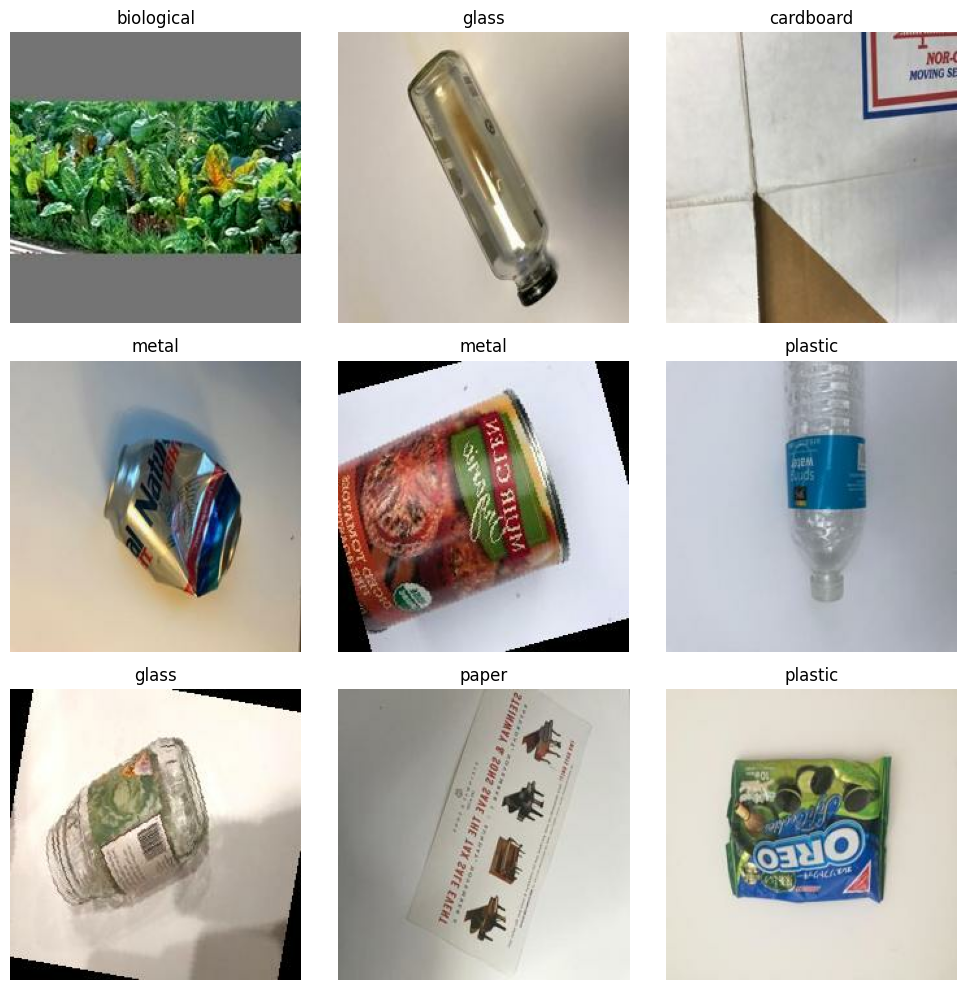

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8).numpy())
        plt.title(index_to_label[int(labels[i].numpy())])
        plt.axis("off")

plt.tight_layout()
plt.show()


## 16. CNN-Modell definieren

Hier wird das neuronale Netzwerk aufgebaut.


In [ ]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1. / 255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(TARGET_CLASSES), activation="softmax")
])


NameError: name 'TARGET_CLASSES' is not defined

## 17. Modell kompilieren

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 18. RestNet50 Model definieren

In [ ]:
RestNet50_model = ResNet50(
   weights='imagenet',       # vortrainiert
   include_top=False,        # ohne alten Klassifikationskopf
   input_shape=(224, 224, 3)
)
for layer in RestNet50_model.layers:
   layer.trainable = False
x = RestNet50_model.output
x = layers.GlobalAveragePooling2D()(x)   # moderner als Flatten
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(6, activation='softmax')(x)
model_resnet = keras.Model(
   inputs=RestNet50_model.input,
   outputs=output
)
model_resnet.summary()
model_resnet.compile(
   optimizer='adam',
   loss='sparse_categorical_crossentropy',
   metrics=['accuracy']
)

## 19 MobileNet Model Definieren

In [ ]:
MobileNet_model = MobileNetV2(
   weights='imagenet',
   include_top=False,
   input_shape=(224, 224, 3)
)
for layer in MobileNet_model.layers:
   layer.trainable = False
x = MobileNet_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(6, activation='softmax')(x)
model_mobilenet = keras.Model(
   inputs=MobileNet_model.input,
   outputs=output
)
model_mobilenet.summary()
model_mobilenet.compile(
   optimizer='adam',
   loss='sparse_categorical_crossentropy',
   metrics=['accuracy']
)
 

## 18. Modelle trainieren

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_cnn = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)


NameError: name 'keras' is not defined

## 19. Accuracy und Loss visualisieren

In [ ]:
acc = history_cnn.history["accuracy"]
val_acc = history_cnn.history["val_accuracy"]
loss = history_cnn.history["loss"]
val_loss = history_cnn.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.tight_layout()
plt.show()


NameError: name 'history_cnn' is not defined

## 20. Testdaten auswerten

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.6981 - loss: 0.9535
Test Loss: 0.9535
Test Accuracy: 0.6981


## 21. Classification Report und Confusion Matrix

              precision    recall  f1-score   support

  biological       0.95      0.90      0.92       105
   cardboard       0.76      0.61      0.67        61
       glass       0.50      0.61      0.55        76
       metal       0.77      0.55      0.64        62
       paper       0.61      0.88      0.72        90
     plastic       0.68      0.49      0.57        73

    accuracy                           0.70       467
   macro avg       0.71      0.67      0.68       467
weighted avg       0.72      0.70      0.70       467

            biological  cardboard  glass  metal  paper  plastic
biological          94          2      4      0      5        0
cardboard            1         37      6      2     12        3
glass                0          2     46      6     14        8
metal                1          1     13     34      9        4
paper                0          2      6      1     79        2
plastic              3          5     17      1     11       36


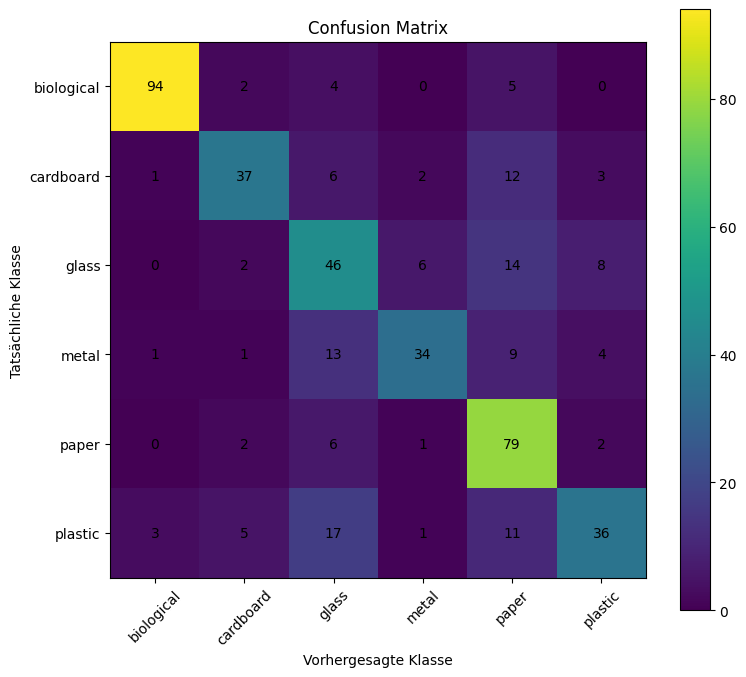

In [ ]:
y_true = []
y_pred = []

for images_batch, labels_batch in test_ds:
    preds = model.predict(images_batch, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES))

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=TARGET_CLASSES, columns=TARGET_CLASSES)

print(cm_df)

plt.figure(figsize=(8, 7))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(TARGET_CLASSES))
plt.xticks(tick_marks, TARGET_CLASSES, rotation=45)
plt.yticks(tick_marks, TARGET_CLASSES)

for i in range(len(TARGET_CLASSES)):
    for j in range(len(TARGET_CLASSES)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Tatsächliche Klasse")
plt.xlabel("Vorhergesagte Klasse")
plt.tight_layout()
plt.show()


# ROC-Kurve

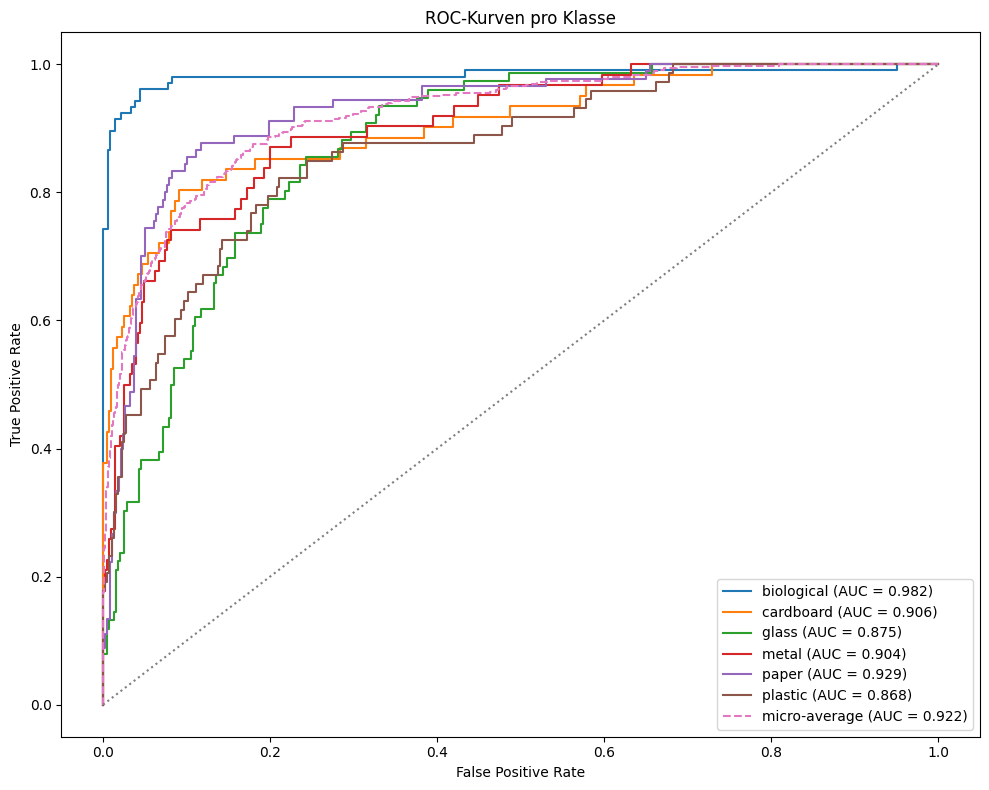

In [ ]:
# ROC-Kurven für Multi-Class (One-vs-Rest)

y_true = []
y_score = []

for images_batch, labels_batch in test_ds:
    preds = model.predict(images_batch, verbose=0)
    y_true.extend(labels_batch.numpy())
    y_score.extend(preds)

y_true = np.array(y_true)
y_score = np.array(y_score)

# True Labels binarisieren
y_true_bin = label_binarize(y_true, classes=np.arange(len(TARGET_CLASSES)))

# ROC pro Klasse berechnen
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(TARGET_CLASSES)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Mikro-Durchschnitt berechnen
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(TARGET_CLASSES):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_name} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    label=f"micro-average (AUC = {roc_auc['micro']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurven pro Klasse")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 22. Zufällige Beispielvorhersagen

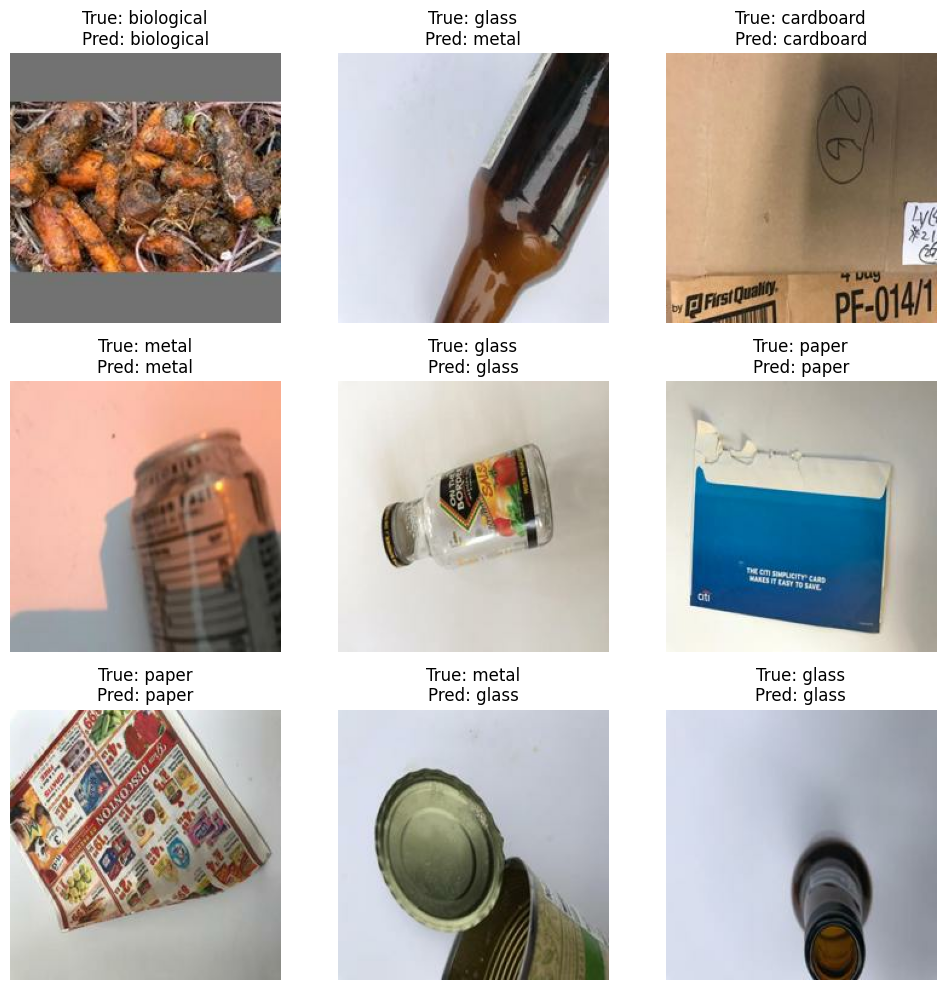

In [ ]:
sample_df = test_df.sample(min(9, len(test_df)), random_state=None)

plt.figure(figsize=(10, 10))

for i, row in enumerate(sample_df.itertuples()):
    img = tf.io.read_file(row.filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img_input = tf.expand_dims(img, axis=0)

    pred = model.predict(img_input, verbose=0)
    pred_class = TARGET_CLASSES[int(np.argmax(pred[0]))]
    true_class = TARGET_CLASSES[int(row.label)]

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(tf.cast(img, tf.uint8).numpy())
    plt.title(f"True: {true_class}\nPred: {pred_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Grad-CAM

Zufällige Klasse: metal
Bild: dataset-split\test\metal\metal129.jpg


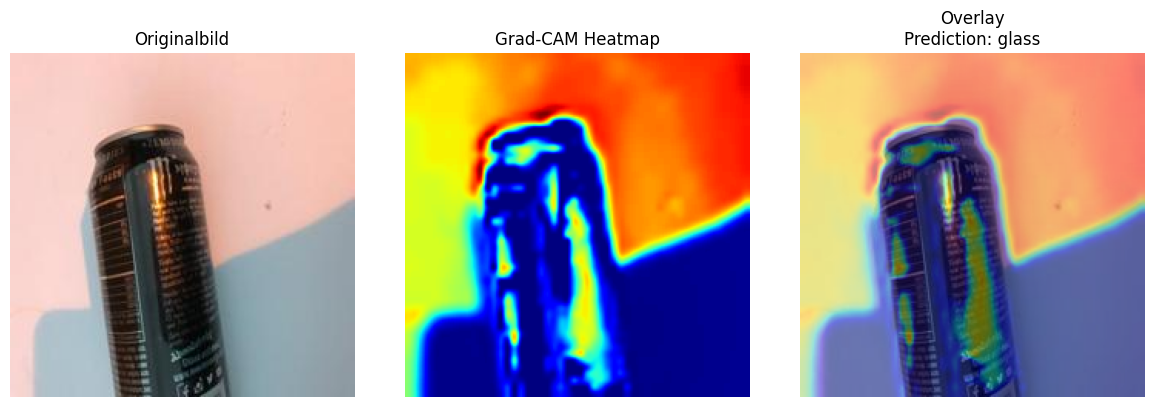

Letzte Conv-Schicht: conv2d_5
Vorhergesagte Klasse: glass


In [ ]:
# =========================
# Grad-CAM (random Bild)
# =========================

def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("Keine Conv2D-Schicht im Modell gefunden.")


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_model = tf.keras.models.Model(model.inputs, last_conv_layer.output)

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input

    start_collecting = False
    for layer in model.layers:
        if layer.name == last_conv_layer_name:
            start_collecting = True
            continue
        if start_collecting:
            x = layer(x)

    classifier_model = tf.keras.models.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_model(img_array, training=False)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs, training=False)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy(), int(pred_index)


def show_gradcam(img_path, model, img_size=(224, 224), alpha=0.4):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img).astype("float32")
    input_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(input_array, verbose=0)
    pred_index = int(np.argmax(preds[0]))
    pred_class = TARGET_CLASSES[pred_index]

    last_conv_layer_name = get_last_conv_layer(model)

    heatmap, _ = make_gradcam_heatmap(
        input_array,
        model,
        last_conv_layer_name,
        pred_index=pred_index
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize(img_size)
    heatmap = np.array(heatmap)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Originalbild")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(heatmap, cmap="jet", alpha=alpha)
    plt.title(f"Overlay\nPrediction: {pred_class}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Letzte Conv-Schicht:", last_conv_layer_name)
    print("Vorhergesagte Klasse:", pred_class)


# =========================
# RANDOM TEST (wichtig)
# =========================

# zufällige Klasse wählen
random_class = random.choice(TARGET_CLASSES)

sample_path = os.path.join("dataset-split", "test", random_class)

if os.path.isdir(sample_path):
    files = os.listdir(sample_path)
    if files:
        random_file = random.choice(files)
        img_path = os.path.join(sample_path, random_file)

        print("Zufällige Klasse:", random_class)
        print("Bild:", img_path)

        show_gradcam(img_path, model, img_size=IMG_SIZE)
    else:
        print("Keine Bilder in Klasse gefunden:", random_class)
else:
    print("Ordner nicht gefunden:", sample_path)

## 23. Modell speichern

Das trainierte Modell wird als `.keras`-Datei gespeichert und kann später wieder geladen werden.  
Diese Datei sollte nicht ins Git-Repo gepusht werden.


In [ ]:
MODEL_PATH = "trash_classifier_6classes.keras"
model.save(MODEL_PATH)
print("Modell gespeichert unter:", MODEL_PATH)


Modell gespeichert unter: trash_classifier_6classes.keras


## 24. Predictor Notebook – Müllerkennung

Dieses Kapitel ist getrennt vom Training und dient nur dazu, mit dem bereits trainierten Modell neue Bilder vorherzusagen.

### Ziel
Du lädst ein beliebiges Bild in den Projektordner oder gibst einen Bildpfad an, und das Modell sagt vorher, zu welcher der folgenden Klassen das Bild gehört:

- `biological`
- `cardboard`
- `glass`
- `metal`
- `paper`
- `plastic`


In [ ]:
REQUIRED_FILE = "trash_classifier_6classes.keras"

def find_project_root_for_model(start_path, required_file=REQUIRED_FILE):
    current = start_path
    while True:
        if required_file in os.listdir(current):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            return None
        current = parent

project_root_for_model = find_project_root_for_model(os.getcwd())

if project_root_for_model is None:
    raise FileNotFoundError(f"'{REQUIRED_FILE}' konnte nicht gefunden werden.")

if os.getcwd() != project_root_for_model:
    os.chdir(project_root_for_model)
    print("Arbeitsverzeichnis gesetzt auf:", project_root_for_model)
else:
    print("Arbeitsverzeichnis war schon korrekt.")


Arbeitsverzeichnis war schon korrekt.


## 25. Modell laden

In [ ]:
MODEL_PATH = "trash_classifier_6classes.keras"
model = keras.models.load_model(MODEL_PATH)

print("Modell erfolgreich geladen.")
model.summary()


Modell erfolgreich geladen.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,509,204 (127.83 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,339,470 (85.22 MB)

## 26. Klassen und Bildgröße festlegen

Diese Werte müssen zur Training-Datei passen.


In [ ]:
TARGET_CLASSES = ["biological", "cardboard", "glass", "metal", "paper", "plastic"]
IMG_SIZE = (224, 224)

print("Klassen:", TARGET_CLASSES)
print("Bildgröße:", IMG_SIZE)


Klassen: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']
Bildgröße: (224, 224)


## 27. Vorhersagefunktion für ein einzelnes Bild

Diese Funktion:
- lädt ein Bild
- passt es auf `224x224` an
- gibt die vorhergesagte Klasse aus
- zeigt zusätzlich die Wahrscheinlichkeiten pro Klasse


In [ ]:
def predict_image(img_path):
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Bild nicht gefunden: {img_path}")

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)[0]
    pred_index = int(np.argmax(preds))
    pred_class = TARGET_CLASSES[pred_index]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis("off")
    plt.show()

    print("Vorhergesagte Klasse:", pred_class)
    print("\nWahrscheinlichkeiten:")
    for class_name, prob in zip(TARGET_CLASSES, preds):
        print(f"  {class_name}: {prob:.4f}")

    return pred_class, preds


## 28. Ein einzelnes Bild testen

Lege ein Bild in deinen Projektordner oder in einen Unterordner und passe den Pfad unten an.

Beispiele:
- `testbild.jpg`
- `bilder/testbild.jpg`
- `src/predict_images/gest.jpg`


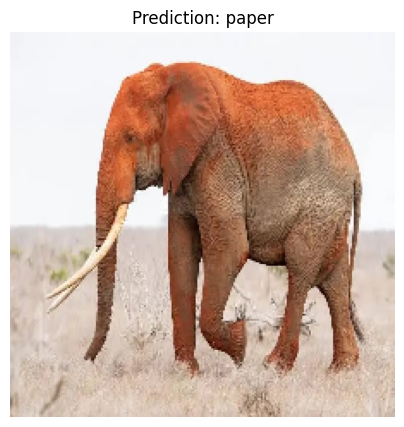

Vorhergesagte Klasse: paper

Wahrscheinlichkeiten:
  biological: 0.0861
  cardboard: 0.0098
  glass: 0.0002
  metal: 0.0269
  paper: 0.8768
  plastic: 0.0002


('paper',
 array([8.6103201e-02, 9.8196967e-03, 1.6808478e-04, 2.6891245e-02,
        8.7682241e-01, 1.9543860e-04], dtype=float32))

In [ ]:
img_path = r"src\predict_images\WhatsApp Image 2026-04-08 at 14.31.34.jpeg"

predict_image(img_path)
# Beispielaufruf:
# predict_image(img_path)


## 29. Mehrere Bilder nacheinander testen

3 Bild(er) gefunden in: src\predict_images

Datei: src\predict_images\gest.jpg


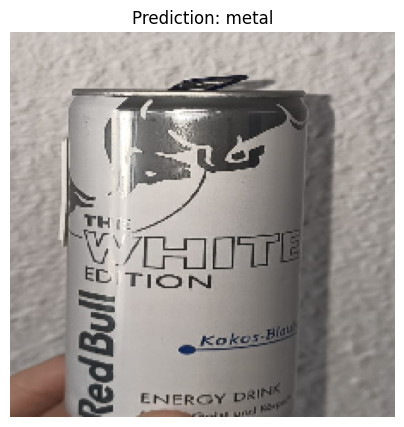

Vorhergesagte Klasse: metal

Wahrscheinlichkeiten:
  biological: 0.0006
  cardboard: 0.0052
  glass: 0.0034
  metal: 0.8039
  paper: 0.1774
  plastic: 0.0094
Datei: src\predict_images\WhatsApp Image 2026-04-08 at 14.30.59.jpeg


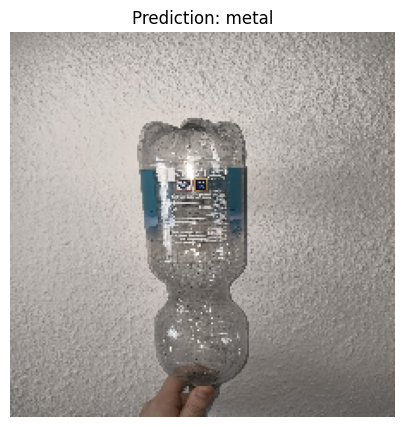

Vorhergesagte Klasse: metal

Wahrscheinlichkeiten:
  biological: 0.0037
  cardboard: 0.0101
  glass: 0.2546
  metal: 0.3307
  paper: 0.2867
  plastic: 0.1142
Datei: src\predict_images\WhatsApp Image 2026-04-08 at 14.31.34.jpeg


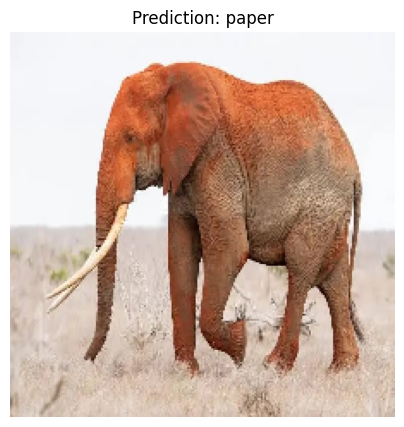

Vorhergesagte Klasse: paper

Wahrscheinlichkeiten:
  biological: 0.0861
  cardboard: 0.0098
  glass: 0.0002
  metal: 0.0269
  paper: 0.8768
  plastic: 0.0002


In [ ]:
def predict_images_from_folder(folder_path):
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Ordner nicht gefunden: {folder_path}")

    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

    if not files:
        print("Keine unterstützten Bilddateien gefunden.")
        return

    print(f"{len(files)} Bild(er) gefunden in: {folder_path}\n")

    for file in files:
        full_path = os.path.join(folder_path, file)
        print("=" * 60)
        print("Datei:", full_path)
        predict_image(full_path)

predict_images_from_folder("src\predict_images")


## 30. Optional: Ein Testbild aus dem vorhandenen Datensatz prüfen

Beispielbild: dataset-split\test\glass\glass107.jpg


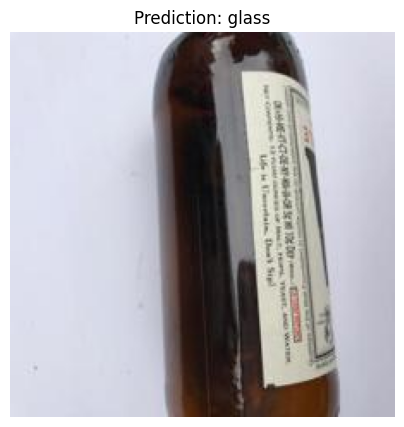

Vorhergesagte Klasse: glass

Wahrscheinlichkeiten:
  biological: 0.0011
  cardboard: 0.0050
  glass: 0.9004
  metal: 0.0426
  paper: 0.0004
  plastic: 0.0505


('glass',
 array([1.0570220e-03, 5.0328807e-03, 9.0041852e-01, 4.2578794e-02,
        3.8719107e-04, 5.0525554e-02], dtype=float32))

In [ ]:
example_path = os.path.join("dataset-split", "test", "glass")

if os.path.isdir(example_path):
    files = os.listdir(example_path)
    if files:
        sample_image = os.path.join(example_path, files[0])
        print("Beispielbild:", sample_image)
    else:
        print("Keine Dateien im Beispielordner gefunden.")
else:
    print("Beispielordner nicht gefunden.")

predict_image(sample_image)


## Fazit

Das Projekt zeigt, wie wichtig eine strukturierte und transparente Datenvorbereitung für den Erfolg eines Machine-Learning-Modells ist. Durch die Vereinheitlichung der Bildgrößen, die gezielte Aufteilung in Trainings-, Validierungs- und Testmengen sowie die datenbasierte Erweiterung mittels Augmentation konnte ein belastbarer und vielseitiger Datensatz geschaffen werden.

Darüber hinaus verdeutlicht das Projekt, dass Data Preparation weit mehr ist als ein technischer Zwischenschritt: Sie entscheidet maßgeblich über die Modellqualität, die Trainingsstabilität und die spätere Anwendbarkeit der KI.
